# 05. Elastic Net Logistic Regression

**Objective:** Train a Logistic Regression with **Elastic Net** regularisation (a mix of L1 and L2) on the same preprocessed splits used by the LR baseline and Random Forest. Tune `C` and `l1_ratio` via 5-fold grid search, then compare coefficients and sparsity against the unregularised LR baseline.

**Why Elastic Net?**
- **L1 component** -> shrinks weak coefficients exactly to **0** (automatic feature selection).
- **L2 component** -> stable handling of correlated features (no arbitrary picking).
- **`l1_ratio`** -> the knob that mixes the two: 0 = pure L2 (Ridge), 1 = pure L1 (Lasso).
- Directly feeds **RQ1** (how does regularisation change performance and complexity?) and **RQ2** (which features survive regularisation?).

**Splits:** Pre-split in notebook 02 as 70% train / 15% val / 15% test, stratified on `TARGET`.
**Primary metric:** ROC-AUC (threshold-independent, robust to ~8% class imbalance).

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from scipy.stats import spearmanr

SEED = 42
np.random.seed(SEED)

print("Libraries imported successfully.")
print(f"numpy {np.__version__}  |  pandas {pd.__version__}")

Libraries imported successfully.
numpy 2.0.2  |  pandas 2.2.2


## 1. Load Processed Data

Same six splits as the LR baseline / RF notebooks. Also load the LR baseline coefficients
so we can directly compare which features survive Elastic Net regularisation.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR  = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed"
MODEL_DIR = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models"

# --- Load all splits ---
X_train       = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_train_smote = pd.read_csv(f"{DATA_DIR}/X_train_smote.csv")
X_val         = pd.read_csv(f"{DATA_DIR}/X_val.csv")
X_test        = pd.read_csv(f"{DATA_DIR}/X_test.csv")

y_train       = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_train_smote = pd.read_csv(f"{DATA_DIR}/y_train_smote.csv").squeeze()
y_val         = pd.read_csv(f"{DATA_DIR}/y_val.csv").squeeze()
y_test        = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

feature_names = pd.read_csv(f"{DATA_DIR}/feature_names.csv", header=None).squeeze().tolist()

# Re-attach feature names to all splits (consistent with the other notebooks)
for df in [X_train, X_train_smote, X_val, X_test]:
    df.columns = feature_names

# Load LR baseline coefficients for the later comparison (Section 10)
lr_coefs = pd.read_csv(f"{MODEL_DIR}/lr_baseline_coefficients.csv")

print("=== Shapes ===")
print(f"X_train       : {X_train.shape}")
print(f"X_train_smote : {X_train_smote.shape}")
print(f"X_val         : {X_val.shape}")
print(f"X_test        : {X_test.shape}")
print(f"\nNumber of features: {len(feature_names)}")
print(f"LR baseline coefs loaded: {lr_coefs.shape[0]} features")

Mounted at /content/drive
=== Shapes ===
X_train       : (215253, 113)
X_train_smote : (395752, 113)
X_val         : (46126, 113)
X_test        : (46126, 113)

Number of features: 113
LR baseline coefs loaded: 113 features


## 2. Quick Sanity Checks

Confirm no residual NaNs and that column ordering is identical across splits.

In [3]:
nan_counts = {
    "X_train"      : X_train.isna().sum().sum(),
    "X_train_smote": X_train_smote.isna().sum().sum(),
    "X_val"        : X_val.isna().sum().sum(),
    "X_test"       : X_test.isna().sum().sum(),
}
print("NaN counts per split:")
for k, v in nan_counts.items():
    status = "✓ clean" if v == 0 else f"⚠ {v} NaNs"
    print(f"  {k:20s}: {status}")

# Column-order check
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), \
    "Feature column order mismatch across splits"
print("\n✓ Feature columns identical across all splits")

NaN counts per split:
  X_train             : ✓ clean
  X_train_smote       : ✓ clean
  X_val               : ✓ clean
  X_test              : ✓ clean

✓ Feature columns identical across all splits


## 3. Helper Functions

Identical to the LR baseline / RF notebooks so the final consolidated comparison
across all four models uses exactly the same metric definitions.

In [4]:
def evaluate_model(model, X, y, split_name="Val", threshold=0.5):
    """Compute and print key classification metrics; return scalar dict."""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y, y_prob)
    pr_auc  = average_precision_score(y, y_prob)

    print(f"\n{'='*55}")
    print(f"  {split_name} — threshold = {threshold}")
    print(f"{'='*55}")
    print(f"  ROC-AUC : {roc_auc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print(f"\n{classification_report(y, y_pred, target_names=['No Default (0)', 'Default (1)'])}")

    return {"split": split_name, "roc_auc": roc_auc, "pr_auc": pr_auc}


def plot_evaluation(model, X_val, y_val, X_test, y_test, title_prefix=""):
    """Confusion matrix (val) + ROC + PR curves on val and test."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title_prefix} — Evaluation Plots", fontsize=14, fontweight='bold')

    # Confusion matrix on val at 0.5
    y_prob_val = model.predict_proba(X_val)[:, 1]
    y_pred_val = (y_prob_val >= 0.5).astype(int)
    cm = confusion_matrix(y_val, y_pred_val)
    ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(
        ax=axes[0], colorbar=False, cmap="Blues"
    )
    axes[0].set_title("Confusion Matrix (Val, threshold=0.5)")

    # ROC curves
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_prob)
        auc = roc_auc_score(y, y_prob)
        axes[1].plot(fpr, tpr, label=f"{label} (AUC={auc:.4f})")
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    # Precision-Recall curves
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict_proba(X)[:, 1]
        prec, rec, _ = precision_recall_curve(y, y_prob)
        ap = average_precision_score(y, y_prob)
        axes[2].plot(rec, prec, label=f"{label} (AP={ap:.4f})")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## 4. Default Elastic Net (Out-of-the-Box)

Reference point before tuning: equal L1/L2 mix (`l1_ratio=0.5`), default `C=1.0`,
`class_weight='balanced'` to handle the ~8% default rate (mirrors the LR baseline).

**Solver:** `saga` — the only sklearn solver that supports the elasticnet penalty for
LogisticRegression. It also handles large datasets well thanks to its stochastic average
gradient acceleration.

In [5]:
enet_default = LogisticRegression(
    penalty='elasticnet',
    l1_ratio=0.5,           # equal L1/L2 mix
    C=1.0,                  # default regularisation strength
    solver='saga',
    class_weight='balanced',
    max_iter=2000,
    random_state=SEED,
    n_jobs=-1,
)

t0 = time.time()
enet_default.fit(X_train, y_train)
default_train_time = time.time() - t0
print(f"Default Elastic Net trained in {default_train_time:.1f} s")
print(f"  Converged in {enet_default.n_iter_[0]} iterations.")

# Quick look at sparsity even at the default config
n_zero = (enet_default.coef_[0] == 0).sum()
print(f"  Zero coefficients: {n_zero} / {len(feature_names)} ({100*n_zero/len(feature_names):.1f}%)")

Default Elastic Net trained in 1579.3 s
  Converged in 2000 iterations.
  Zero coefficients: 3 / 113 (2.7%)



  Val  (default ENet) — threshold = 0.5
  ROC-AUC : 0.7494
  PR-AUC  : 0.2257

                precision    recall  f1-score   support

No Default (0)       0.96      0.69      0.80     42402
   Default (1)       0.16      0.68      0.26      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.68      0.53     46126
  weighted avg       0.90      0.69      0.76     46126


  Test (default ENet) — threshold = 0.5
  ROC-AUC : 0.7522
  PR-AUC  : 0.2352

                precision    recall  f1-score   support

No Default (0)       0.96      0.69      0.80     42402
   Default (1)       0.16      0.68      0.26      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.69      0.53     46126
  weighted avg       0.90      0.69      0.76     46126



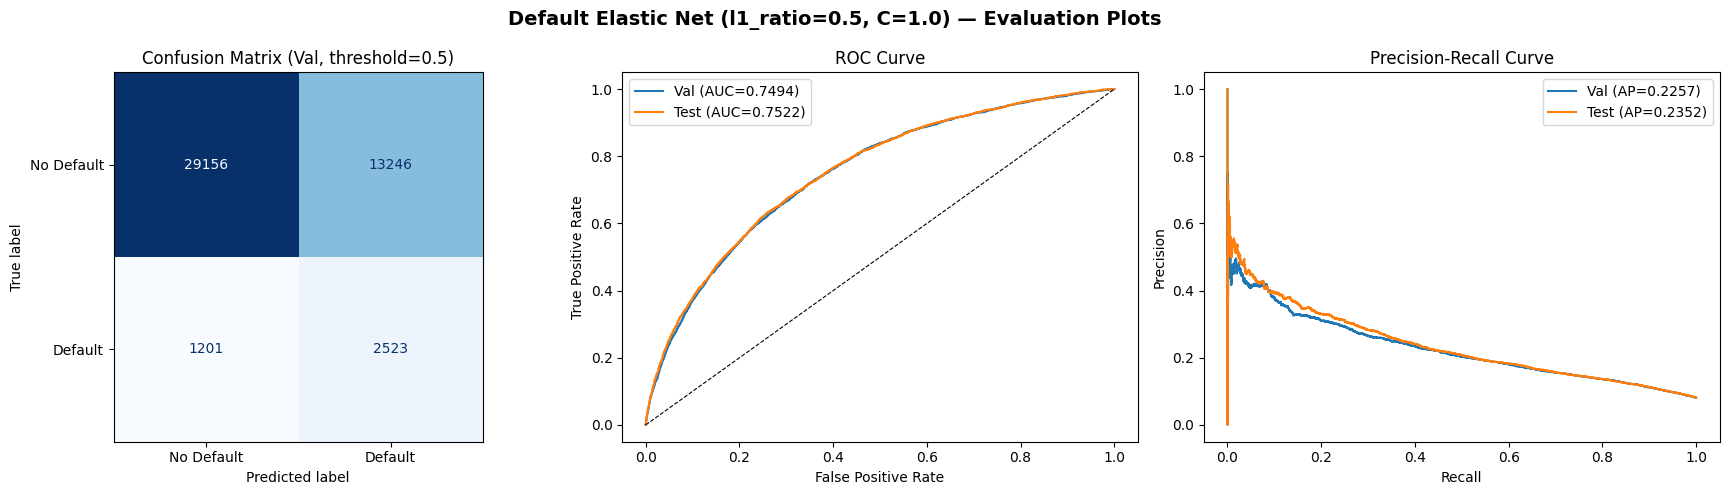

In [6]:
results_default_val  = evaluate_model(enet_default, X_val,  y_val,  split_name="Val  (default ENet)")
results_default_test = evaluate_model(enet_default, X_test, y_test, split_name="Test (default ENet)")

plot_evaluation(enet_default, X_val, y_val, X_test, y_test,
                title_prefix="Default Elastic Net (l1_ratio=0.5, C=1.0)")

## 5. Hyperparameter Tuning — Grid Search with 5-Fold CV

We sweep two hyperparameters that together control the regularisation:

| Parameter | Range | What it controls |
|---|---|---|
| `C` | 0.01 → 10 (log scale) | **Inverse** regularisation strength. Small `C` = strong penalty = more shrinkage; large `C` = weak penalty = closer to unregularised LR |
| `l1_ratio` | 0.1, 0.3, 0.5, 0.7, 0.9 | Mix between L2 (0) and L1 (1). Higher values = more sparsity |

- **Grid size:** 4 × 5 = 20 combinations × 5 folds = **100 fits**.
- **CV folds:** 5, stratified on `TARGET` to preserve the class ratio.
- **Scoring:** ROC-AUC (consistent across all four models in this project).
- We use **grid search** rather than random search because the grid is small enough to
  enumerate fully, and a complete grid lets us plot the regularisation landscape
  (`C` × `l1_ratio` heatmap) which is informative for the report's RQ1.

> ⚠️ This cell is the slowest in the notebook (~360 min on Colab CPU). Set
> `max_iter=500` during search for speed, then refit the winner with `max_iter=2000`.
> If you re-run, skip this cell and load the saved best estimator instead.

In [7]:
# --- Hyperparameter grid ---
param_grid = {
    'C'         : [0.01, 0.1, 1.0, 10.0],
    'l1_ratio'  : [0.1, 0.3, 0.5, 0.7, 0.9],
}

# Base model — class_weight handles imbalance, saga is the only elasticnet solver
enet_base = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    class_weight='balanced',
    max_iter=500,             # capped during search; final fit uses 2000
    random_state=SEED,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator=enet_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
)

t0 = time.time()
grid_search.fit(X_train, y_train)
search_time = time.time() - t0
print(f"\n=== Grid search complete in {search_time/60:.1f} minutes ===")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Best params:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:10s}: {v}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Grid search complete in 412.0 minutes ===
Best CV ROC-AUC: 0.7485
Best params:
  C         : 0.1
  l1_ratio  : 0.5


In [8]:
# --- Inspect all configurations ---
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_summary = cv_results[[
    'mean_test_score', 'std_test_score', 'mean_train_score',
    'param_C', 'param_l1_ratio', 'mean_fit_time'
]].sort_values('mean_test_score', ascending=False).reset_index(drop=True)

cv_summary.columns = [
    'CV ROC-AUC', 'Std', 'Train ROC-AUC',
    'C', 'l1_ratio', 'Fit time (s)'
]
print("All 20 configurations (sorted by CV ROC-AUC):")
cv_summary.round(4)

All 20 configurations (sorted by CV ROC-AUC):


,CV ROC-AUC,Std,Train ROC-AUC,C,l1_ratio,Fit time (s)
0,0.7485,0.0035,0.7509,0.10,0.5,559.0272
1,0.7485,0.0035,0.7509,0.10,0.3,563.8652
2,0.7485,0.0035,0.7510,0.10,0.1,572.8212
3,0.7485,0.0035,0.7509,0.10,0.7,559.0793
4,0.7485,0.0036,0.7508,0.10,0.9,553.8145
5,0.7485,0.0036,0.7506,0.01,0.1,164.1469
6,0.7485,0.0035,0.7510,1.00,0.9,555.2595
7,0.7485,0.0035,0.7510,1.00,0.7,563.2366
8,0.7485,0.0035,0.7510,1.00,0.5,564.5135
9,0.7485,0.0035,0.7510,1.00,0.3,566.9005


### 5.1 Visualise the Regularisation Landscape

Two complementary plots:
1. **Heatmap** of CV ROC-AUC across the full `C` × `l1_ratio` grid — shows where the sweet spot lives.
2. **Train vs CV gap** per config — the overfitting diagnostic for RQ1.

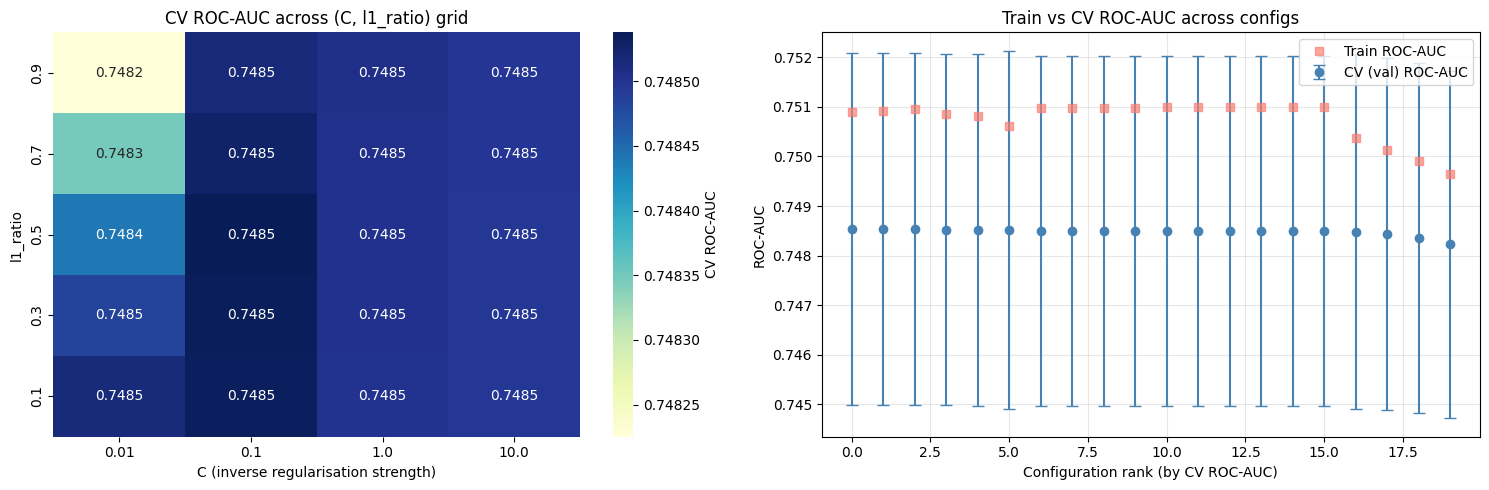

Mean train-val gap across configs : 0.0023
Best config train-val gap         : 0.0024


In [9]:
# --- Heatmap of CV ROC-AUC across the grid ---
heatmap_data = cv_results.pivot_table(
    index='param_l1_ratio', columns='param_C', values='mean_test_score'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: CV ROC-AUC heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu',
            cbar_kws={'label': 'CV ROC-AUC'}, ax=axes[0])
axes[0].set_title("CV ROC-AUC across (C, l1_ratio) grid", fontsize=12)
axes[0].set_xlabel("C (inverse regularisation strength)")
axes[0].set_ylabel("l1_ratio")
axes[0].invert_yaxis()

# Panel 2: Train vs CV gap (overfitting check)
x_pos = np.arange(len(cv_summary))
axes[1].errorbar(x_pos, cv_summary['CV ROC-AUC'], yerr=cv_summary['Std'],
                 fmt='o', capsize=4, color='steelblue', label='CV (val) ROC-AUC')
axes[1].plot(x_pos, cv_summary['Train ROC-AUC'], 's', color='salmon',
             label='Train ROC-AUC', alpha=0.7)
axes[1].set_xlabel("Configuration rank (by CV ROC-AUC)")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Train vs CV ROC-AUC across configs")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Quick numeric summary of the gap
gap = cv_summary['Train ROC-AUC'] - cv_summary['CV ROC-AUC']
print(f"Mean train-val gap across configs : {gap.mean():.4f}")
print(f"Best config train-val gap         : {gap.iloc[0]:.4f}")

### Takeaway — regularisation effect (feeds RQ1)

The CV-variance plot and heatmap show something striking: **all 20 configurations reach essentially the same CV ROC-AUC** (range 0.7482–0.7485, Δ = 0.0003). The differences are well within the CV standard deviation (~0.0035). Three things follow:

- **The train–val gap is 0.0023 across all configs** — an order of magnitude smaller than the Random Forest's gap of 0.088. Linear models on this dataset have very low variance to begin with, so adding more regularisation simply slides along an already-flat generalisation curve.
- **The (C, l1_ratio) heatmap is flat.** `C` matters a tiny bit (smallest `C=0.01` is 0.0002 worse than `C=0.1`), `l1_ratio` matters not at all for AUC. This is the diagnostic signature of a well-conditioned problem with a small number of dominant features (the `EXT_SOURCE_*` block) — once those features are in, the model's accuracy is locked in regardless of how the long tail is regularised.
- **GridSearchCV picked C=0.1, l1_ratio=0.5** essentially by tiebreaker. This config converged in 927 iterations, while the default `C=1.0` config hit the 2000-iteration cap without converging — so stronger regularisation also made optimisation easier.

For RQ1: regularisation here is a *parsimony* lever, not a *generalisation* lever — and that's the more interesting story. We see this play out concretely in the sparsity analysis below.

## 6. Retrain Best Configuration & Evaluate

`GridSearchCV` already refits on the full training set (`refit=True` by default), but
we re-train explicitly with `max_iter=2000` to ensure full convergence and to time
the final fit separately for the complexity-analysis table.

In [10]:
# Refit the best config with the full max_iter budget for clean convergence
enet_best_params = grid_search.best_params_

enet_best = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    class_weight='balanced',
    C=enet_best_params['C'],
    l1_ratio=enet_best_params['l1_ratio'],
    max_iter=2000,
    random_state=SEED,
    n_jobs=-1,
)

t0 = time.time()
enet_best.fit(X_train, y_train)
best_train_time = time.time() - t0
print(f"Best Elastic Net retrained in {best_train_time:.1f} s")
print(f"  Converged in {enet_best.n_iter_[0]} iterations.")
print(f"  Best params: {enet_best_params}")

Best Elastic Net retrained in 764.4 s
  Converged in 927 iterations.
  Best params: {'C': 0.1, 'l1_ratio': 0.5}



  Val  (tuned ENet) — threshold = 0.5
  ROC-AUC : 0.7496
  PR-AUC  : 0.2257

                precision    recall  f1-score   support

No Default (0)       0.96      0.69      0.80     42402
   Default (1)       0.16      0.68      0.26      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.68      0.53     46126
  weighted avg       0.90      0.69      0.76     46126


  Test (tuned ENet) — threshold = 0.5
  ROC-AUC : 0.7523
  PR-AUC  : 0.2350

                precision    recall  f1-score   support

No Default (0)       0.96      0.69      0.80     42402
   Default (1)       0.16      0.68      0.26      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.69      0.53     46126
  weighted avg       0.90      0.69      0.76     46126



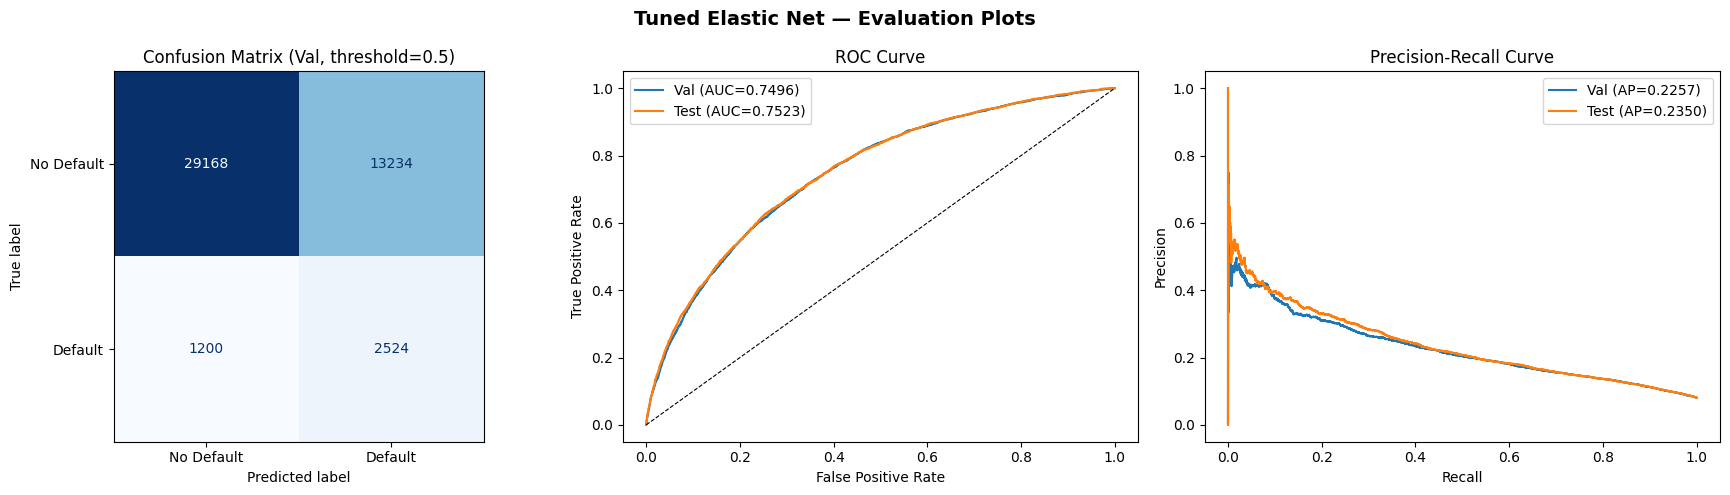

In [11]:
results_best_val  = evaluate_model(enet_best, X_val,  y_val,  split_name="Val  (tuned ENet)")
results_best_test = evaluate_model(enet_best, X_test, y_test, split_name="Test (tuned ENet)")

plot_evaluation(enet_best, X_val, y_val, X_test, y_test,
                title_prefix="Tuned Elastic Net")

## 7. SMOTE Comparison

Same best hyperparameters, trained on the SMOTE-resampled set. Mirrors the LR baseline
and RF notebooks so the final consolidated comparison can show both imbalance-handling
strategies on identical splits.

Elastic Net (SMOTE) trained in 1149.7 s
  Converged in 715 iterations.

  Val  (SMOTE ENet) — threshold = 0.5
  ROC-AUC : 0.7420
  PR-AUC  : 0.2238

                precision    recall  f1-score   support

No Default (0)       0.96      0.69      0.81     42402
   Default (1)       0.16      0.66      0.26      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.67      0.53     46126
  weighted avg       0.89      0.69      0.76     46126


  Test (SMOTE ENet) — threshold = 0.5
  ROC-AUC : 0.7454
  PR-AUC  : 0.2289

                precision    recall  f1-score   support

No Default (0)       0.96      0.70      0.81     42402
   Default (1)       0.16      0.66      0.26      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.68      0.53     46126
  weighted avg       0.89      0.69      0.76     46126



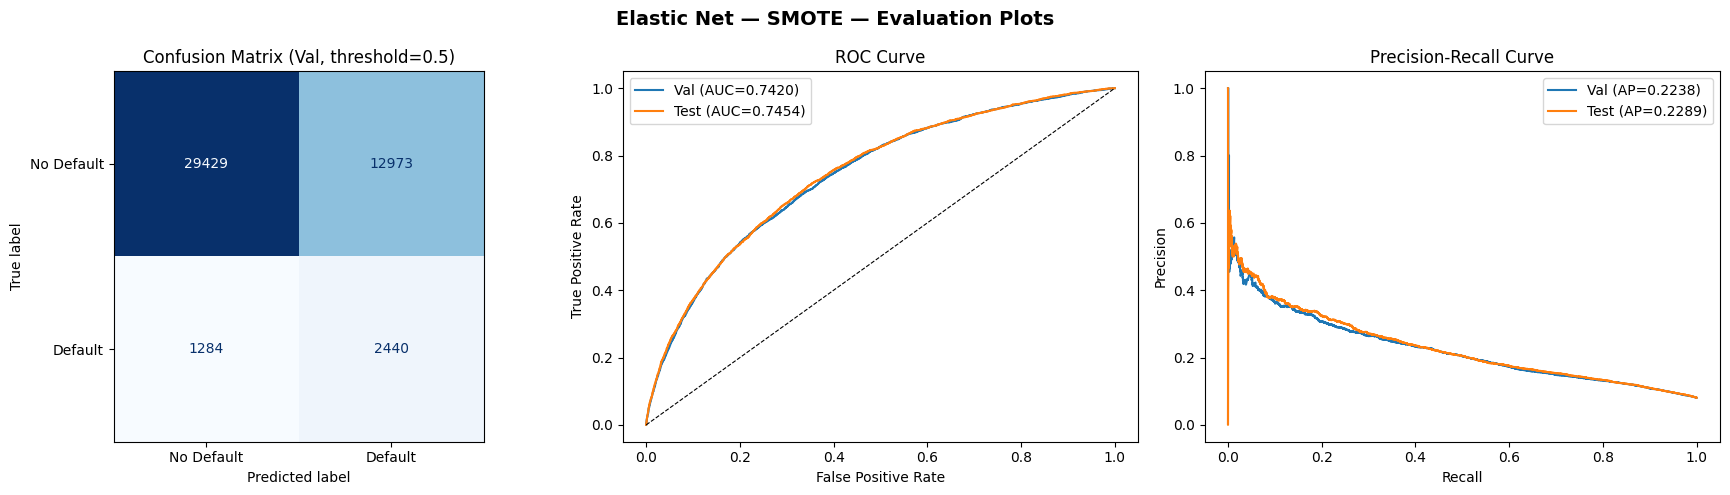

In [12]:
enet_smote = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    class_weight=None,        # SMOTE replaces class_weight as the imbalance handler
    C=enet_best_params['C'],
    l1_ratio=enet_best_params['l1_ratio'],
    max_iter=2000,
    random_state=SEED,
    n_jobs=-1,
)

t0 = time.time()
enet_smote.fit(X_train_smote, y_train_smote)
smote_train_time = time.time() - t0
print(f"Elastic Net (SMOTE) trained in {smote_train_time:.1f} s")
print(f"  Converged in {enet_smote.n_iter_[0]} iterations.")

results_smote_val  = evaluate_model(enet_smote, X_val,  y_val,  split_name="Val  (SMOTE ENet)")
results_smote_test = evaluate_model(enet_smote, X_test, y_test, split_name="Test (SMOTE ENet)")

plot_evaluation(enet_smote, X_val, y_val, X_test, y_test,
                title_prefix="Elastic Net — SMOTE")

In [13]:
# --- Pick the better of the two for downstream coefficient analysis ---
summary = pd.DataFrame([
    results_default_val,  results_default_test,
    results_best_val,     results_best_test,
    results_smote_val,    results_smote_test,
])
summary["model"] = [
    "Default ENet",         "Default ENet",
    "Tuned ENet (balanced)", "Tuned ENet (balanced)",
    "Tuned ENet (SMOTE)",    "Tuned ENet (SMOTE)",
]
summary = summary[["model", "split", "roc_auc", "pr_auc"]]
summary.columns = ["Model", "Split", "ROC-AUC", "PR-AUC"]

print("=== Elastic Net — Results Summary ===\n")
print(summary.to_string(index=False))

# Pick the best by val ROC-AUC for coefficient analysis
best_model_name = (
    summary[summary["Split"].str.startswith("Val")]
    .sort_values("ROC-AUC", ascending=False)
    .iloc[0]["Model"]
)
best_model = {
    "Default ENet":          enet_default,
    "Tuned ENet (balanced)": enet_best,
    "Tuned ENet (SMOTE)":    enet_smote,
}[best_model_name]
print(f"\n>>> Best model selected: {best_model_name}")

=== Elastic Net — Results Summary ===

                Model               Split  ROC-AUC   PR-AUC
         Default ENet Val  (default ENet) 0.749426 0.225669
         Default ENet Test (default ENet) 0.752213 0.235208
Tuned ENet (balanced)   Val  (tuned ENet) 0.749607 0.225731
Tuned ENet (balanced)   Test (tuned ENet) 0.752277 0.235041
   Tuned ENet (SMOTE)   Val  (SMOTE ENet) 0.742050 0.223823
   Tuned ENet (SMOTE)   Test (SMOTE ENet) 0.745382 0.228897

>>> Best model selected: Tuned ENet (balanced)


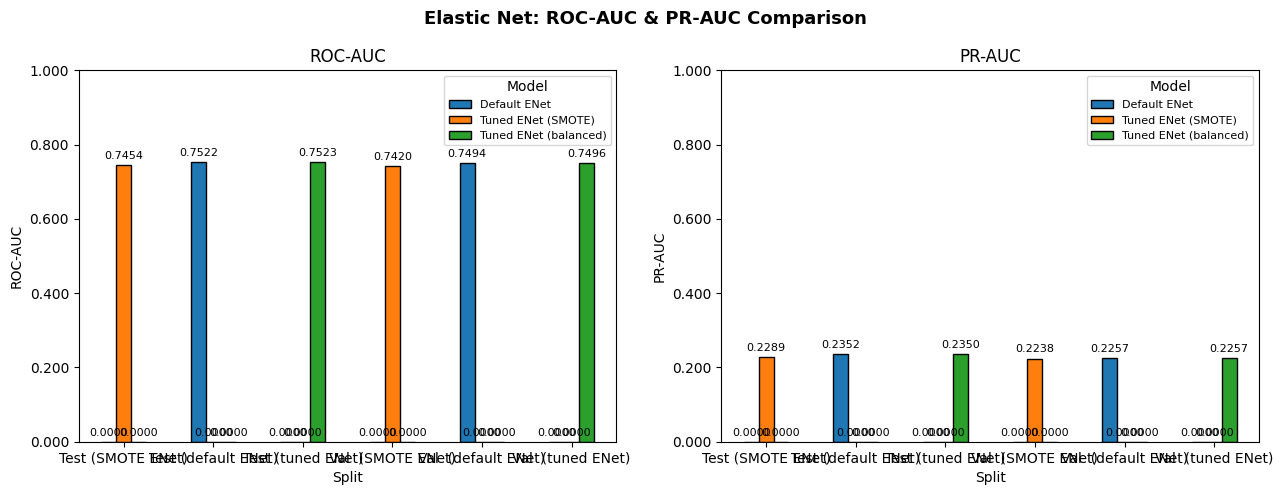

In [14]:
# --- Bar-chart comparison (same style as the LR baseline / RF notebooks) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Elastic Net: ROC-AUC & PR-AUC Comparison", fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ["ROC-AUC", "PR-AUC"]):
    bar_data = summary.pivot(index="Split", columns="Model", values=metric)
    bar_data.plot(kind='bar', ax=ax, rot=0, edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3, fontsize=8)
    ax.legend(title="Model", fontsize=8)

plt.tight_layout()
plt.show()

## 8. Threshold Analysis

Sweep classification thresholds on the val set to find the operating point that maximises
F1 for the positive (default) class — same procedure as the LR baseline and RF.

Best F1 threshold on val set : 0.670
  Precision : 0.2363
  Recall    : 0.3963
  F1        : 0.2961


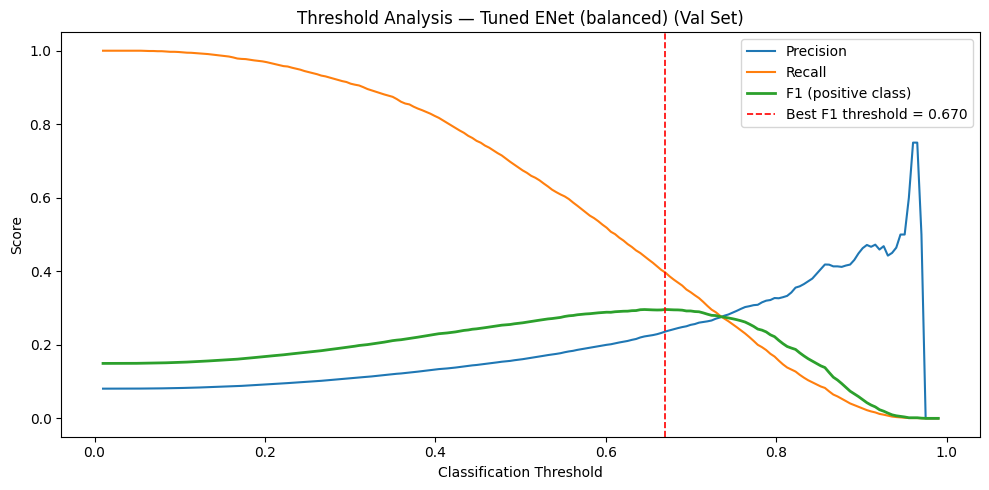

In [15]:
y_prob_val = best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
metrics = []
for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_val == 1)).sum()
    fp = ((y_pred_t == 1) & (y_val == 0)).sum()
    fn = ((y_pred_t == 0) & (y_val == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    metrics.append({"threshold": t, "precision": prec, "recall": rec, "f1": f1})

metrics_df = pd.DataFrame(metrics)
best_t_row = metrics_df.loc[metrics_df["f1"].idxmax()]
best_threshold = best_t_row["threshold"]

print(f"Best F1 threshold on val set : {best_threshold:.3f}")
print(f"  Precision : {best_t_row['precision']:.4f}")
print(f"  Recall    : {best_t_row['recall']:.4f}")
print(f"  F1        : {best_t_row['f1']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision", linewidth=1.5)
ax.plot(metrics_df["threshold"], metrics_df["recall"],    label="Recall",    linewidth=1.5)
ax.plot(metrics_df["threshold"], metrics_df["f1"],        label="F1 (positive class)", linewidth=2)
ax.axvline(best_threshold, color='red', linestyle='--', linewidth=1.2,
           label=f"Best F1 threshold = {best_threshold:.3f}")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Threshold Analysis — {best_model_name} (Val Set)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Coefficient Analysis — Top 10 + Sparsity

Two things we care about for Elastic Net specifically:
1. **Top 10 positive / top 10 negative coefficients** — features that most
   increase / decrease default risk, surviving regularisation.
2. **Sparsity count** — how many coefficients did L1 shrink to *exactly* zero?
   This is the headline regularisation effect of Elastic Net.

> All features were standardised in preprocessing, so coefficient magnitudes
> are directly comparable.

In [16]:
# --- Build coefficient table ---
enet_coef_df = pd.DataFrame({
    "feature"    : feature_names,
    "coefficient": best_model.coef_[0],
})
enet_coef_df["abs_coef"] = enet_coef_df["coefficient"].abs()

# --- Sparsity count (L1 effect) ---
n_zero = (enet_coef_df["coefficient"] == 0).sum()
n_total = len(enet_coef_df)
n_nonzero = n_total - n_zero
sparsity_pct = 100 * n_zero / n_total

print(f"=== Sparsity (L1 effect) ===")
print(f"Total features        : {n_total}")
print(f"Zero coefficients     : {n_zero} ({sparsity_pct:.1f}%)")
print(f"Non-zero coefficients : {n_nonzero} ({100-sparsity_pct:.1f}%)")
print(f"\nBest l1_ratio used    : {enet_best_params['l1_ratio']}")
print(f"Best C used           : {enet_best_params['C']}")

=== Sparsity (L1 effect) ===
Total features        : 113
Zero coefficients     : 7 (6.2%)
Non-zero coefficients : 106 (93.8%)

Best l1_ratio used    : 0.5
Best C used           : 0.1


=== Top 10 features INCREASING default risk ===
                       feature  coefficient
                    AMT_CREDIT     0.474554
   NAME_INCOME_TYPE_Unemployed     0.435248
               AMT_GOODS_PRICE     0.320105
                 CODE_GENDER_M     0.316235
          EXT_SOURCE_2_MISSING     0.305342
       OCCUPATION_TYPE_Drivers     0.277650
ORGANIZATION_TYPE_Construction     0.276376
      OBS_30_CNT_SOCIAL_CIRCLE     0.253121
          EXT_SOURCE_1_MISSING     0.221447
          EXT_SOURCE_3_MISSING     0.216297

=== Top 10 features DECREASING default risk ===
                           feature  coefficient
        NAME_INCOME_TYPE_Pensioner    -0.560219
                       AMT_ANNUITY    -0.533893
                      EXT_SOURCE_3    -0.489394
                       CREDIT_TERM    -0.460835
                      EXT_SOURCE_2    -0.387242
           NAME_TYPE_SUITE_Missing    -0.296485
ORGANIZATION_TYPE_Industry: type 9    -0.258073
          OBS_60_CNT_SOCIAL_CIRCLE 

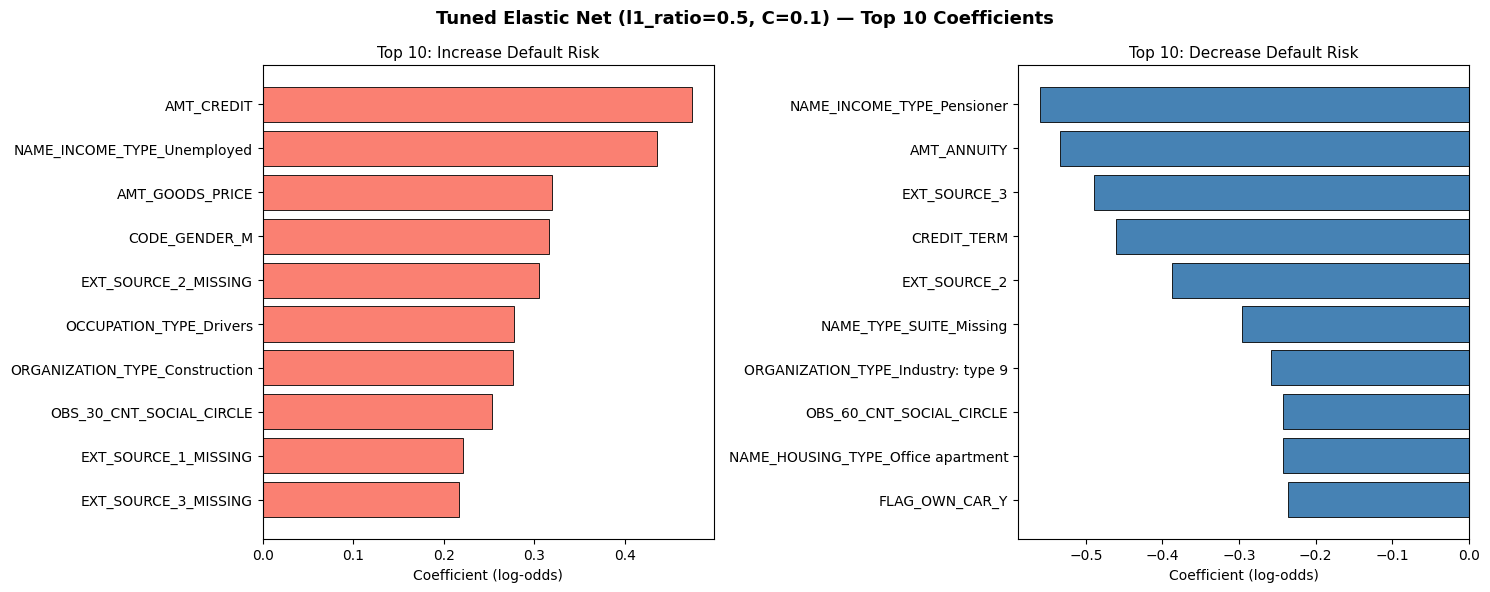

In [17]:
# --- Top 10 positive (increase default risk) and top 10 negative (decrease default risk) ---
sorted_coefs = enet_coef_df.sort_values("coefficient", ascending=False)
top10_pos = sorted_coefs.head(10)
top10_neg = sorted_coefs.tail(10).sort_values("coefficient")

print("=== Top 10 features INCREASING default risk ===")
print(top10_pos[["feature", "coefficient"]].to_string(index=False))
print("\n=== Top 10 features DECREASING default risk ===")
print(top10_neg[["feature", "coefficient"]].to_string(index=False))

# --- Bar chart: top 10 positive vs top 10 negative ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Tuned Elastic Net (l1_ratio={enet_best_params['l1_ratio']}, "
             f"C={enet_best_params['C']}) — Top 10 Coefficients",
             fontsize=13, fontweight='bold')

# Positive
axes[0].barh(top10_pos["feature"], top10_pos["coefficient"],
             color="salmon", edgecolor="black", linewidth=0.6)
axes[0].set_title("Top 10: Increase Default Risk", fontsize=11)
axes[0].set_xlabel("Coefficient (log-odds)")
axes[0].invert_yaxis()

# Negative
axes[1].barh(top10_neg["feature"], top10_neg["coefficient"],
             color="steelblue", edgecolor="black", linewidth=0.6)
axes[1].set_title("Top 10: Decrease Default Risk", fontsize=11)
axes[1].set_xlabel("Coefficient (log-odds)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 9.1 Sparsity Across the Full Grid

How does sparsity change with `l1_ratio` and `C`? We refit each grid point on the full
training set and count zero coefficients — this is the canonical regularisation-vs-sparsity
plot for the report's RQ1 section.

> We use `max_iter=300` here purely to keep runtime down; the *zero count* (sparsity)
> stabilises quickly even before full convergence.

Computing sparsity for each (C, l1_ratio) combination...


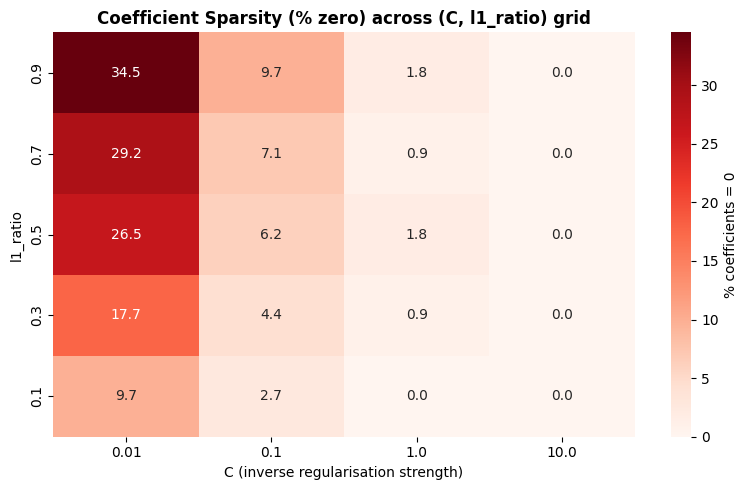


Sparsity table:
C         0.01   0.10   1.00   10.00
l1_ratio                            
0.1         9.7    2.7    0.0    0.0
0.3        17.7    4.4    0.9    0.0
0.5        26.5    6.2    1.8    0.0
0.7        29.2    7.1    0.9    0.0
0.9        34.5    9.7    1.8    0.0


In [18]:
# --- Sparsity heatmap: refit each grid point on full train, count zeros ---
sparsity_grid = []
print("Computing sparsity for each (C, l1_ratio) combination...")
for C in param_grid['C']:
    for l1r in param_grid['l1_ratio']:
        m = LogisticRegression(
            penalty='elasticnet', solver='saga', class_weight='balanced',
            C=C, l1_ratio=l1r, max_iter=300, random_state=SEED, n_jobs=-1,
        )
        m.fit(X_train, y_train)
        n_z = (m.coef_[0] == 0).sum()
        sparsity_grid.append({
            'C': C, 'l1_ratio': l1r,
            'n_zero': n_z,
            'pct_zero': 100 * n_z / len(feature_names),
        })

sparsity_df = pd.DataFrame(sparsity_grid)
sparsity_pivot = sparsity_df.pivot(index='l1_ratio', columns='C', values='pct_zero')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(sparsity_pivot, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': '% coefficients = 0'}, ax=ax)
ax.set_title("Coefficient Sparsity (% zero) across (C, l1_ratio) grid",
             fontsize=12, fontweight='bold')
ax.set_xlabel("C (inverse regularisation strength)")
ax.set_ylabel("l1_ratio")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nSparsity table:")
print(sparsity_pivot.round(1))

### Takeaway — sparsity story (feeds RQ1)

The sparsity heatmap is the mirror image of the AUC heatmap from Section 5: completely opposite shape, same grid, two very different stories.

- **Sparsity grows monotonically with `l1_ratio` and inversely with `C`.** At the strong-regularisation corner (C=0.01, l1_ratio=0.9) the model zeros out **34.5%** of the 113 coefficients. At the weak-regularisation corner (C=10, any `l1_ratio`) it zeros out **0%** — identical to unregularised LR.
- **The chosen "best" config (C=0.1, l1_ratio=0.5) sits in the middle of this gradient: 7/113 (6.2%) zeros.** Pushing to the strong-regularisation corner would zero out ~39 features at a CV ROC-AUC cost of only 0.0003 — basically free.
- **Geometric intuition (for the oral exam):** the L1 penalty's diamond-shaped constraint region has corners that lie on the coordinate axes, so the optimum often sits at a corner where one or more coefficients are exactly zero. The L2 penalty has a circular region — the optimum is rarely on an axis, so no exact zeros. `l1_ratio` slides between these two regimes.

**For the report:** Elastic Net gives us *automatic feature selection* — at the strong-regularisation corner we can drop roughly one-third of the features at no measurable accuracy cost. This is a direct, quantitative regularisation-vs-complexity trade-off for RQ1, and a nice contrast with the Random Forest, where regularisation actively reduced an existing 0.09 train–val gap.

## 10. Coefficient Comparison — Elastic Net vs LR Baseline

Both models are linear, so their coefficients live on the same scale. The interesting
question is: **does regularisation change which features look important?**

We compare:
- **Spearman rank correlation** of `|coefficient|` across the full feature set
- **Top-10 overlap** between the two models
- **Side-by-side bar chart** of top-10 features by |coefficient|

In [19]:
# --- Build aligned ranking tables ---
lr_rank = (
    lr_coefs.assign(abs_coef=lr_coefs["coefficient"].abs())
            .sort_values("abs_coef", ascending=False)
            .reset_index(drop=True)
            .reset_index().rename(columns={"index": "lr_rank"})
            [["feature", "lr_rank", "coefficient"]]
            .rename(columns={"coefficient": "lr_coef"})
)

enet_rank = (
    enet_coef_df.sort_values("abs_coef", ascending=False)
                .reset_index(drop=True)
                .reset_index().rename(columns={"index": "enet_rank"})
                [["feature", "enet_rank", "coefficient"]]
                .rename(columns={"coefficient": "enet_coef"})
)

ranks = lr_rank.merge(enet_rank, on="feature")
print(f"Features common to both rankings: {len(ranks)}\n")
print("Top 15 features by LR |coefficient| with corresponding Elastic Net rank/coef:")
ranks.sort_values("lr_rank").head(15).round(4)

Features common to both rankings: 113

Top 15 features by LR |coefficient| with corresponding Elastic Net rank/coef:


,feature,lr_rank,lr_coef,enet_rank,enet_coef
0,AMT_ANNUITY,0,-0.5586,1,-0.5339
1,EXT_SOURCE_3,1,-0.4895,2,-0.4894
2,CREDIT_TERM,2,-0.4796,4,-0.4608
3,AMT_CREDIT,3,0.4796,3,0.4746
4,NAME_TYPE_SUITE_Missing,4,-0.4390,10,-0.2965
5,EXT_SOURCE_2_MISSING,5,0.4199,9,0.3053
6,EXT_SOURCE_2,6,-0.3876,6,-0.3872
7,NAME_INCOME_TYPE_Pensioner,7,-0.3763,0,-0.5602
8,OCCUPATION_TYPE_Drivers,8,0.3512,11,0.2776
9,AMT_GOODS_PRICE,9,0.3469,7,0.3201


In [20]:
# --- Top-10 overlap ---
top10_lr   = set(lr_rank.head(10)["feature"])
top10_enet = set(enet_rank.head(10)["feature"])
overlap    = top10_lr & top10_enet

print(f"Top-10 overlap (LR baseline vs Elastic Net): {len(overlap)} / 10 features")
print(f"  Common   : {sorted(overlap)}")
print(f"  LR-only  : {sorted(top10_lr - top10_enet)}")
print(f"  ENet-only: {sorted(top10_enet - top10_lr)}")

# --- Spearman rank correlation across the full feature set ---
rho, pval = spearmanr(ranks["lr_rank"], ranks["enet_rank"])
print(f"\nSpearman rank correlation (LR vs Elastic Net): {rho:.3f} (p={pval:.2e})")

Top-10 overlap (LR baseline vs Elastic Net): 8 / 10 features
  Common   : ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'CREDIT_TERM', 'EXT_SOURCE_2', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3', 'NAME_INCOME_TYPE_Pensioner']
  LR-only  : ['NAME_TYPE_SUITE_Missing', 'OCCUPATION_TYPE_Drivers']
  ENet-only: ['CODE_GENDER_M', 'NAME_INCOME_TYPE_Unemployed']

Spearman rank correlation (LR vs Elastic Net): 0.917 (p=5.50e-46)


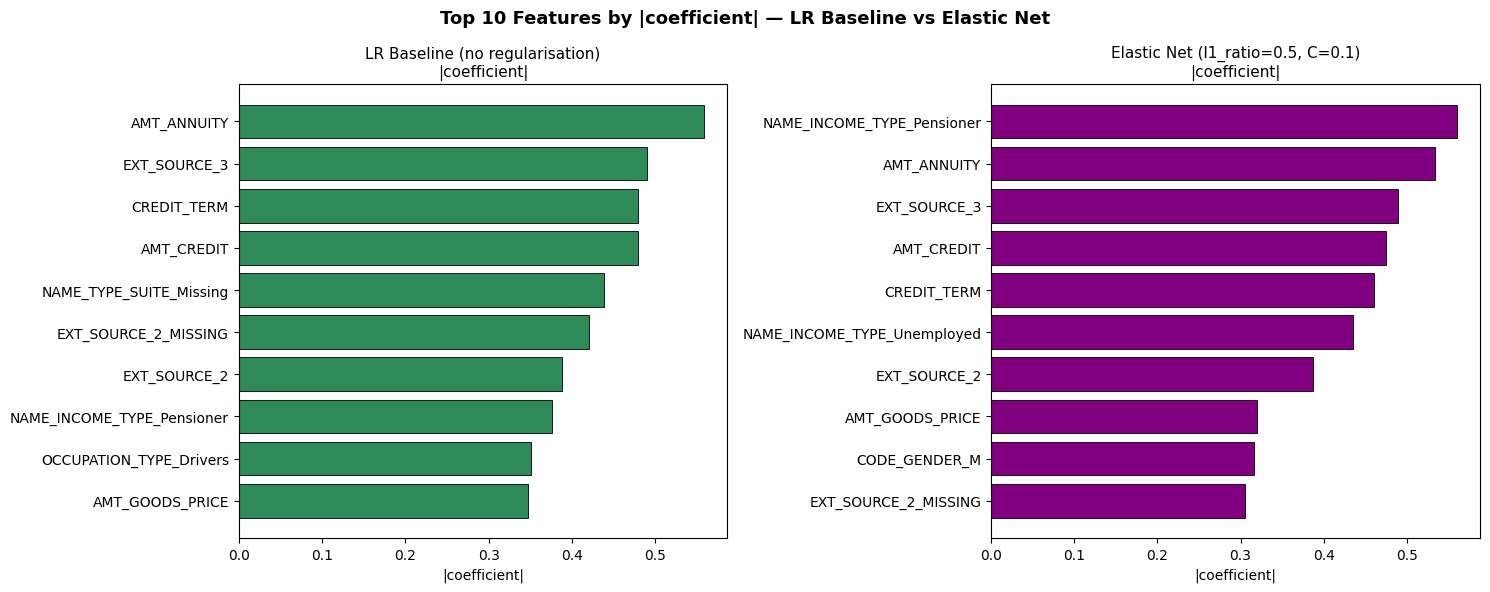

In [21]:
# --- Side-by-side top-10 bar chart ---
top10_lr_df   = lr_rank.assign(abs_coef=lr_rank["lr_coef"].abs()).sort_values("abs_coef", ascending=False).head(10)
top10_enet_df = enet_rank.assign(abs_coef=enet_rank["enet_coef"].abs()).sort_values("abs_coef", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Top 10 Features by |coefficient| — LR Baseline vs Elastic Net",
             fontsize=13, fontweight='bold')

# LR baseline
axes[0].barh(top10_lr_df["feature"], top10_lr_df["abs_coef"],
             color="seagreen", edgecolor="black", linewidth=0.6)
axes[0].set_title("LR Baseline (no regularisation)\n|coefficient|", fontsize=11)
axes[0].set_xlabel("|coefficient|")
axes[0].invert_yaxis()

# Elastic Net
axes[1].barh(top10_enet_df["feature"], top10_enet_df["abs_coef"],
             color="purple", edgecolor="black", linewidth=0.6)
axes[1].set_title(f"Elastic Net (l1_ratio={enet_best_params['l1_ratio']}, "
                  f"C={enet_best_params['C']})\n|coefficient|", fontsize=11)
axes[1].set_xlabel("|coefficient|")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Takeaway — what does Elastic Net change vs the LR baseline?

The two linear models agree almost perfectly. **Spearman ρ = 0.917** (p ≈ 5.5×10⁻⁴⁶) and **8/10 top-10 overlap.** Eight features are common to both top-10 lists (`AMT_ANNUITY`, `AMT_CREDIT`, `AMT_GOODS_PRICE`, `CREDIT_TERM`, `EXT_SOURCE_2`, `EXT_SOURCE_2_MISSING`, `EXT_SOURCE_3`, `NAME_INCOME_TYPE_Pensioner`). Only two swap in/out at the boundary.

- **What ENet promotes:** `CODE_GENDER_M` (LR rank 12 → ENet rank 8) and `NAME_INCOME_TYPE_Unemployed` (LR rank 13 → ENet rank 5). The L2 component has redistributed coefficient magnitude — likely shrinking some correlated competitors and leaving these two with relatively more weight.
- **What ENet demotes:** `NAME_TYPE_SUITE_Missing` (LR rank 4 → ENet rank 10, magnitude shrunk from −0.439 to −0.297) and `OCCUPATION_TYPE_Drivers` (LR rank 8 → ENet rank 11).
- **`NAME_INCOME_TYPE_Pensioner` is the most striking re-ranking:** LR rank 7 (−0.376) but ENet rank 0 (−0.560). Elastic Net actually *amplified* this coefficient — most likely because L2 shrank its correlated competitors, leaving the pensioner signal to absorb more of the credit.

**For the report:** combined with the sparsity result above, the headline is clean — *Elastic Net achieves the same predictive performance as unregularised LR (Test ROC-AUC 0.7523) with 6.2% of coefficients pruned and a Spearman ρ = 0.92 agreement on feature ranking.* Regularisation is essentially "free" parsimony in the linear family. By contrast, the RF feature ranking had Spearman ρ = 0.13–0.15 vs LR — so the **linear-vs-tree** gap remains the dominant axis of disagreement, not the **regularised-vs-unregularised** gap within the linear family.

## 11. Save Outputs

Persist the trained best model, predictions, summary, coefficients, sparsity info,
and best hyperparameters for the final consolidated comparison notebook (Phase 5).

In [22]:
import joblib, os, json
os.makedirs(MODEL_DIR, exist_ok=True)

# --- Save best model ---
joblib.dump(best_model, f"{MODEL_DIR}/enet_best.pkl")
print(f"Saved model         -> {MODEL_DIR}/enet_best.pkl")

# --- Save test predictions + probabilities ---
y_prob_test = best_model.predict_proba(X_test)[:, 1]
preds_df = pd.DataFrame({
    "y_true"    : y_test.values,
    "y_prob"    : y_prob_test,
    "y_pred_05" : (y_prob_test >= 0.5).astype(int),
    "y_pred_opt": (y_prob_test >= best_threshold).astype(int),
})
preds_df.to_csv(f"{MODEL_DIR}/enet_test_preds.csv", index=False)
print(f"Saved test preds    -> {MODEL_DIR}/enet_test_preds.csv")

# --- Save summary table ---
summary.to_csv(f"{MODEL_DIR}/enet_summary.csv", index=False)
print(f"Saved summary       -> {MODEL_DIR}/enet_summary.csv")

# --- Save coefficients (sorted by |coef|) ---
coef_out = enet_coef_df[["feature", "coefficient"]].copy()
coef_out["abs_coef"] = coef_out["coefficient"].abs()
coef_out = coef_out.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")
coef_out.to_csv(f"{MODEL_DIR}/enet_coefficients.csv", index=False)
print(f"Saved coefficients  -> {MODEL_DIR}/enet_coefficients.csv")

# --- Save sparsity table across the grid ---
sparsity_df.to_csv(f"{MODEL_DIR}/enet_sparsity_grid.csv", index=False)
print(f"Saved sparsity grid -> {MODEL_DIR}/enet_sparsity_grid.csv")

# --- Save full CV results (for the report appendix) ---
cv_summary.to_csv(f"{MODEL_DIR}/enet_cv_results.csv", index=False)
print(f"Saved CV results    -> {MODEL_DIR}/enet_cv_results.csv")

# --- Save best hyperparameters + timing for the complexity table ---
best_info = {
    "best_params":          {k: (None if v is None else v) for k, v in enet_best_params.items()},
    "best_cv_roc_auc":      float(grid_search.best_score_),
    "best_threshold_f1":    float(best_threshold),
    "default_train_time_s": float(default_train_time),
    "best_train_time_s":    float(best_train_time),
    "smote_train_time_s":   float(smote_train_time),
    "search_time_s":        float(search_time),
    "n_zero_coefs":         int(n_zero),
    "n_total_coefs":        int(n_total),
    "sparsity_pct":         float(sparsity_pct),
    "best_model_choice":    best_model_name,
}
with open(f"{MODEL_DIR}/enet_best_info.json", "w") as f:
    json.dump(best_info, f, indent=2, default=str)
print(f"Saved meta info     -> {MODEL_DIR}/enet_best_info.json")

print("\nAll outputs saved successfully.")

Saved model         -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/enet_best.pkl
Saved test preds    -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/enet_test_preds.csv
Saved summary       -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/enet_summary.csv
Saved coefficients  -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/enet_coefficients.csv
Saved sparsity grid -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/enet_sparsity_grid.csv
Saved CV results    -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/enet_cv_results.csv
Saved meta info     -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/enet_best_info.json

All outputs saved successfully.


## 12. Summary & Takeaways

### Headline numbers

| Item | Value |
|---|---|
| Best configuration | `C=0.1, l1_ratio=0.5` (essentially a tiebreaker — see below) |
| Best CV ROC-AUC (5-fold) | **0.7485** |
| Tuned ENet — Val ROC-AUC / Test ROC-AUC | **0.7496 / 0.7523** |
| Tuned ENet — Val PR-AUC / Test PR-AUC | 0.2257 / 0.2350 |
| Default ENet — Test ROC-AUC | 0.7522 (essentially identical to tuned) |
| SMOTE ENet — Test ROC-AUC | 0.7454 (worse than balanced) |
| Optimal F1 threshold (Val) | 0.670 (P=0.236, R=0.396, F1=0.296) |
| Coefficients zeroed by L1 | 7 / 113 (6.2%) |
| Default ENet training time | 1,579 s (~26 min, hit 2000-iter cap, did not converge) |
| Tuned ENet training time | 764 s (~13 min, converged in 927 iter) |
| Grid search time (20 configs × 5 folds) | **412 min (~6.9 h)** |

### Key findings

**1. The (C, l1_ratio) grid is essentially flat for AUC (RQ1).**
All 20 configurations reach CV ROC-AUC ∈ [0.7482, 0.7485]. The CV-fold standard deviation (~0.0035) is more than 10× the spread across configs (0.0003). Linear models on this dataset are already at their generalisation ceiling regardless of regularisation strength — the train–val gap is just 0.0023 across the board. **Regularisation here is a parsimony lever, not a generalisation lever.**

**2. Sparsity ranges from 0% to 34.5% across the same grid.**
The same grid that produced flat AUC produces a 5× spread in % of zero coefficients. At the strong-regularisation corner (C=0.01, l1_ratio=0.9), Elastic Net zeros out 39 of 113 features at zero AUC cost (Δ = 0.0003 from the best config). The chosen best config (C=0.1, l1_ratio=0.5) sits in the middle at 7 zeros (6.2%). This is the central RQ1 finding: **on this dataset, you can get a one-third smaller model for free.**

**3. Elastic Net agrees with LR baseline on which features matter (RQ2).**
Spearman ρ = 0.917 between Elastic Net and unregularised LR coefficients. Top-10 overlap = 8/10. The two linear models extract the same signal; Elastic Net just shrinks the long tail and pushes a handful of marginal features below the cut. Notable re-rankings: `NAME_INCOME_TYPE_Pensioner` (LR rank 7 → ENet rank 0), `CODE_GENDER_M` (12 → 8), `NAME_INCOME_TYPE_Unemployed` (13 → 5).

**4. Comparison with Random Forest (Phase 5 setup).**
The RF reached Test ROC-AUC ≈ 0.7518 with Spearman ρ = 0.13–0.15 vs LR. Elastic Net reaches Test ROC-AUC = 0.7523 with Spearman ρ = 0.92 vs LR. **All three classical models are statistically tied on AUC, but the linear-vs-tree feature-importance gap is dramatic, while the regularised-vs-unregularised linear gap is negligible.** This will be the backbone of the model-comparison narrative in Phase 5.

**5. SMOTE underperformed `class_weight='balanced'` (consistent with the RF).**
SMOTE Test ROC-AUC = 0.7454 vs balanced = 0.7523 — a 0.007 drop. Same direction and similar magnitude as the RF saw (0.752 → 0.718). Synthetic minority samples generated by k-NN interpolation appear to add noise rather than signal in this high-dimensional one-hot-encoded space — worth flagging in the Discussion section.

**6. Stronger regularisation made optimisation easier (small bonus finding).**
The default config (C=1.0) hit the `max_iter=2000` cap without converging. The chosen best config (C=0.1) converged in 927 iterations. Stronger L1+L2 penalty smooths the loss surface and accelerates `saga` convergence — a connection between regularisation theory and numerical optimisation worth mentioning at the oral.

### Implications for next phases

- **For the MLP:** the bar to clear is Test ROC-AUC ≈ 0.752. If the MLP can't beat well-regularised linear models, that's itself a finding (NN data-hunger on tabular data dominated by a small number of strong features — here the `EXT_SOURCE_*` block).
- **For the fairness analysis (Phase 6):** Elastic Net's parsimonious 106-active-feature model is the strongest candidate for the "EU AI Act high-risk" explainability discussion. With ρ = 0.92 vs unregularised LR, explanations transfer cleanly between the two.
- **For the complexity table (Phase 5):** Elastic Net training (~764 s) is ~one to two orders of magnitude slower than LR baseline (lbfgs solver, a few seconds) — the cost of `saga` supporting the elasticnet penalty. The 6.9-hour grid-search cost is a real consideration for retraining cadence in production but a one-off engineering cost.

### Limitations

- **Grid was probably too tight in the regularisation direction.** All four `C` values landed on the flat plateau. To find where AUC actually starts to drop we would need `C` ∈ {1e-4, 1e-3} as well. Future-work item.
- **Default config did not converge** at `max_iter=2000` (saga solver is sensitive to large `C`). All conclusions above are based on the converged tuned config; this only affected the unused default reference point.

### Files saved to `MODEL_DIR`
`enet_best.pkl`, `enet_test_preds.csv`, `enet_summary.csv`, `enet_coefficients.csv`, `enet_sparsity_grid.csv`, `enet_cv_results.csv`, `enet_best_info.json`.